# RQ5: Can Sentiment from Twitter, Reddit, Google Trends, and Disagreement improve next-day BTC return prediction vs a price-only baseline?

### Hypothesis 
A predictive model including sentiment features achieves better accuracy than a model using only past Bitcoin prices.

## Import Function and libraries
- Helper function that is defined to load the data safely with predefined schema.
- Helper module for RQ5 to reduce code overhead in notebook
- Import needed libraries

In [1]:
import sys

# Get the path to the helper functions
sys.path.append('../src/')

import importlib
import helper.RQ5 as RQ5
import helper.data as data

# Reload helper functions
importlib.reload(RQ5)
importlib.reload(data)


import polars as pl

### Prepare model and data for training
- Data are loaded as RQ4
- Using predefined function in RQ5.py to prepare the data for training

In short, `model_prepare(...)` builds **daily modeling datasets** that combine market data with sentiment and trends, then splits them into train and validation sets.

The returned data will contains:
- Derived features
    - `sent_1to5`: **Daily sentiment and disagreement features** from Reddit + Twitter.
    - `btc_daily_1to5`: **Daily BTC metrics** (e.g. instability/volatility) computed from 1-minute data.
    - Combined with **Google Trends features**.
- Target: `absret_daily` (absolute daily Bitcoin return)


In [2]:
tweets_1to4 = data.load_data_sentiment("../data/tweets_training.csv")
tweets_5 = data.load_data_sentiment("../data/sentiment/tweets_5_sent.csv")
reddit_1to4 = data.load_data_sentiment("../data/reddit_training.csv")
reddit_5 = data.load_data_sentiment("../data/sentiment/reddit_5_sent.csv")
btc_1to4 = data.load_btc("../data/btc_training.csv")
btc_5 = data.load_btc("../data/btc_5.csv")


reddit_1to5 = pl.concat([reddit_1to4, reddit_5], how="vertical").sort("timestamp")
tweets_1to5 = pl.concat([tweets_1to4, tweets_5], how="vertical").sort("timestamp")
btc_1to5    = pl.concat([btc_1to4, btc_5], how="vertical").sort("timestamp")
google_1to5 = RQ5.load_google(path="../data/google_1to5.csv")

train_df, val_df = RQ5.model_prepare(
    reddit_1to5=reddit_1to5, 
    tweets_1to5=tweets_1to5, 
    btc_1to5=btc_1to5,
    gt_1to5=google_1to5
)
print("train days:", train_df.height)
print("val days:",   val_df.height)

train days: 241
val days: 60


### Training Model 
Then we using defined function to train our model `training_model_rq5(training_df, validation_df)`
- Iterates over a set of **predefined model specifications** (`rq5_models()`).
- For each model:
    - Fits an **OLS regression** on the training data and **predicts on validation data** using `fit_predict`.
    - Computes **validation performance metrics**:
    - **RMSE** (root mean squared error)
    - **MAE** (mean absolute error)
- Collects:
    - `metrics`: performance summary per model
    - `results`: full model outputs (coefficients, predictions, etc.)
-  **Returns:** `(metrics, results)`

### Evaluate Model Performance
We can evaluate model still using the same error functions: 
- **Root Mean Squared Error (RMSE)**: Computes the average sqaured prediction error, penalizes large errros more heavily and good for measuring overall prediction accuracy. Defined as:
$$\text{RMSE}=\sqrt{\frac{1}{n}\sum_{i=1}^n (y_i-\hat{y_i})^2}$$
- **Mean Absolute Error**: Computes the average absolute prediction error, measures typical prediction error, less sensitive to outliers than RMSE. Defines as:
$$\text{MAE}=\frac{1}{n}\sum_{i=1}^n|y_i-\hat{y_i}|$$


Then evaluate using `report_best_models_rq5(metrics)`:

-  Takes a list of model performance results (`metrics`).
-  **Finds the best-performing model**:
    - One with the **lowest RMSE**
    - One with the **lowest MAE**
- **Prints** the best RMSE and MAE results.
-  **Returns** the names of the best models according to each metric:

```python
{"rmse": <best model by RMSE>, "mae": <best model by MAE>}
```

In [3]:
metrics, results = RQ5.training_model_rq5(train_df, val_df)

**selects and reports the best-performing models** based on validation errors.


In [4]:
best = RQ5.report_best_models_rq5(metrics)

Best RMSE: {'model': 'AR1_plus_ALL', 'rmse': 0.015169037801155439, 'mae': 0.012327766531459006}
Best MAE : {'model': 'AR1_plus_D_VAR_D_STD_D_IQR_D_MAD_7D_D_GAP_7D', 'rmse': 0.016445041565233624, 'mae': 0.01227411204277094}


### Plotting Model predictions
Finaly we can plot our model performance in the graphs. for all model prediction and cumulative graphs

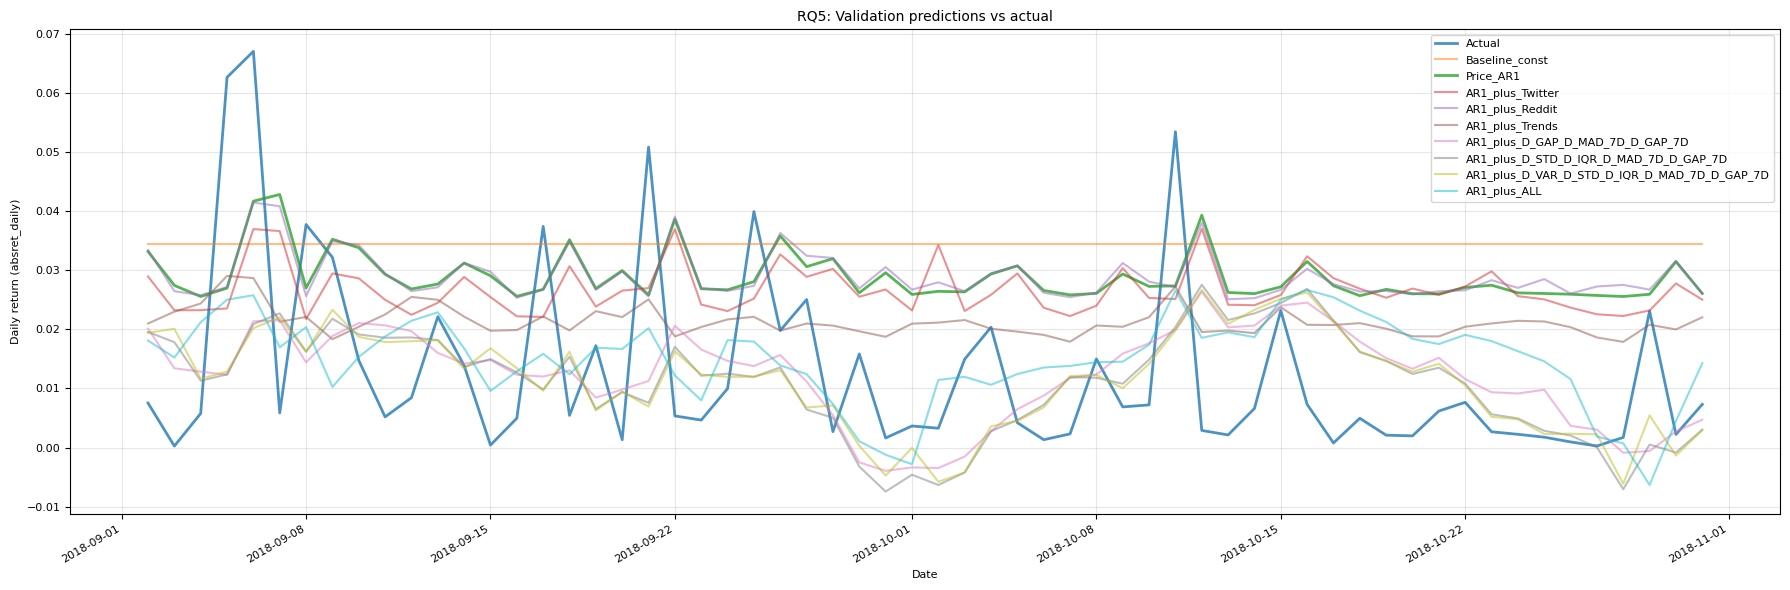

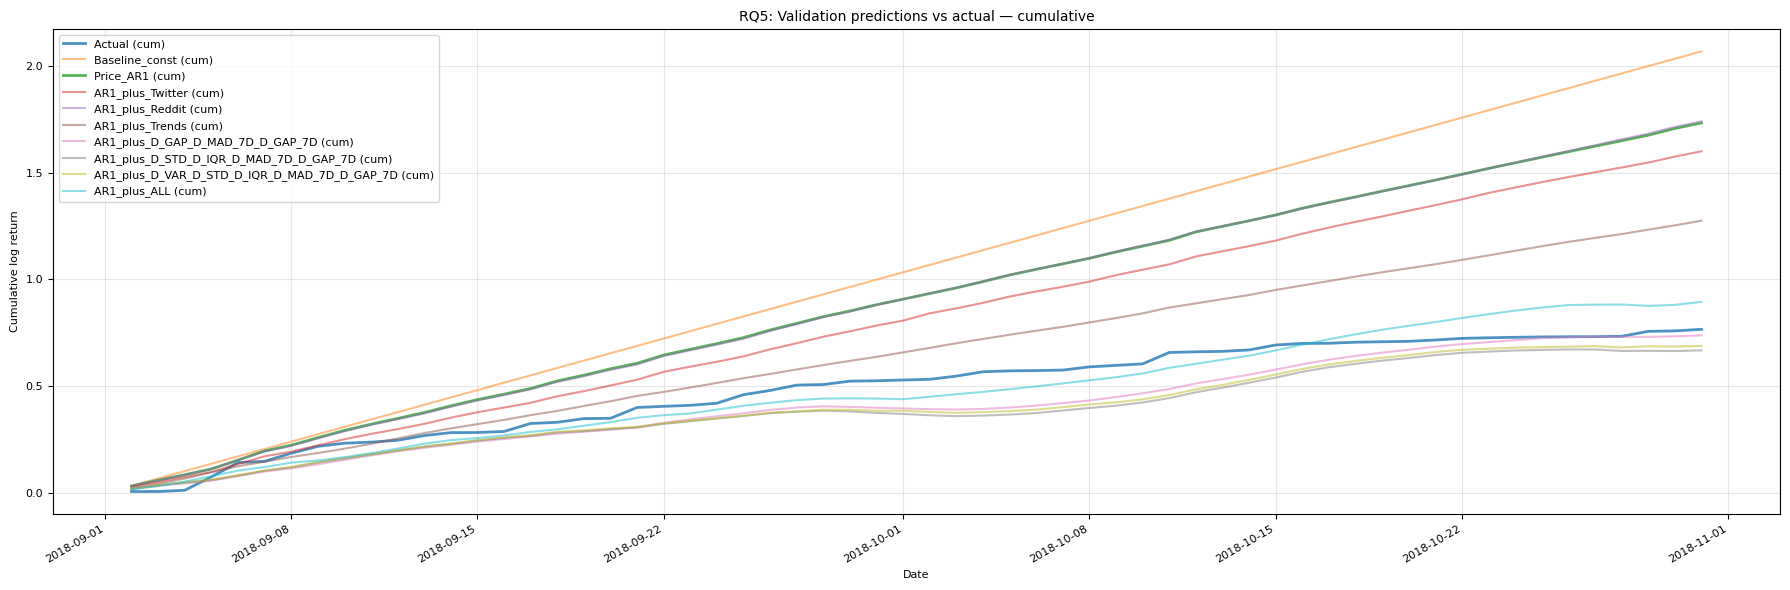

In [5]:
RQ5.plot_all_model_predictions(val_df, results)


### Hypothesis is proven
We can clearly see that model with sentiment features are performing better than the baseline based on the error function. therefore we can conclude that our hypiothesis is corret. I.e. A predictive model including sentiment features achieves better accuracy than a model using only past Bitcoin prices.